<div align="center"><img src="https://drive.google.com/uc?export=download&id=1RHAO53B5qNbHqrWObI7623jtlLZBWD73" width="300" alt="NOVA IMS Logo">

  <br>
  <br>
  <b>Master in Data Science and Advanced Analytics</b>

  <b>Deep Learning</b>

  2025–2026
</div>

<b><h1> Skin Lesions </h1><b>

<table>
  <thead style="color:#96d9f0;">
    <tr>
      <th>Name</th>
      <th>Student ID</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Bruna Caetano</td>
      <td>20250526</td>
    </tr>
    <tr>
      <td>Fausto Gomez</td>
      <td>20221915</td>
    </tr>
    <tr>
      <td>Francisco Graça</td>
      <td>20250471</td>
    </tr>
    <tr>
      <td>Maria Francisca Gonçalves</td>
      <td>20221942</td>
    </tr>
    <tr>
      <td>Tomás Gonçalves</td>
      <td>20221894</td>
    </tr>
  </tbody>
</table>

# **0. Set-Up**

In [1]:
#Libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
from PIL import Image
from tqdm import tqdm
import scipy.stats as ss
import torch
import torchvision.transforms as T
import torchvision.models as models
from tqdm import tqdm
from collections import Counter
import umap
from PIL import Image
import cv2
import missingno as msno
import matplotlib.image as mpimg
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder

c:\Users\faust\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
base_path = "./data" 

image_dirs = [
    "HAM10000_images_part_1",
    "HAM10000_images_part_2",
    "ISIC2018_Task3_Test_Images"
]

image_paths = []

In [3]:
metadata_path = os.path.join(base_path, "HAM10000_metadata")
metadata_df = pd.read_csv(metadata_path, sep=",")
metadata_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [4]:
merged_df_path = os.path.join(base_path, "merged_df_cleaned.csv")
merged_df = pd.read_csv(merged_df_path, sep=",")
merged_df.head()

,image_id,image_path,lesion_id,dx,dx_type,age,sex,localization,dataset,img_mean,img_std,width,height,umap_dist,is_outlier,cleaned_path
0,ISIC_0028291,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...,HAM_0006253,mel,histo,65.0,male,back,vidir_modern,0.666128,0.154030,600,450,1.802865,False,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...
1,ISIC_0028308,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...,HAM_0003752,bkl,histo,50.0,female,chest,rosendahl,0.621565,0.091182,600,450,0.999917,False,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...
2,ISIC_0028286,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...,HAM_0005470,nv,follow_up,30.0,female,trunk,vidir_molemax,0.662481,0.200656,600,450,3.714251,False,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...
3,ISIC_0028288,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...,HAM_0004709,mel,histo,65.0,male,back,rosendahl,0.694768,0.142947,600,450,1.436014,False,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...
4,ISIC_0028313,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...,HAM_0004166,nv,follow_up,45.0,male,back,vidir_molemax,0.672074,0.212765,600,450,3.718916,False,/content/drive/MyDrive/MDSAA-DS/DL-project/dat...


# **1. Exploratory Data Analysis (EDA)**

### Diagnostic Class Definitions (dx)

| Code  | Meaning                                                                                                         |
|-------|-----------------------------------------------------------------------------------------------------------------|
| akiec | Actinic keratoses and intraepithelial carcinoma (Bowen’s disease).                                              |
| bcc   | Basal cell carcinoma.                                                                                           |
| bkl   | Benign keratosis-like lesions (solar lentigines, seborrheic keratoses, lichen‑planus–like keratoses).           |
| df    | Dermatofibroma.                                                                                                 |
| mel   | Melanoma.                                                                                                       |
| nv    | Melanocytic nevi.                                                                                               |
| vasc  | Vascular lesions (angiomas, angiokeratomas, pyogenic granulomas, hemorrhage).                                   |

### HAM10000 Metadata Dictionary


| Variable        | Description                                                                                           |
|-----------------|-------------------------------------------------------------------------------------------------------|
| image_id        | Unique identifier for each dermoscopic image (ISIC format).                                           |
| image_path      | Full filesystem path (cloud) to the stored image used for loading during preprocessing or training.           |
| lesion_id       | Identifier for the underlying skin lesion.              |
| dx              | Diagnostic label (one of the 7 HAM10000 classes: akiec, bcc, bkl, df, mel, nv, vasc).                 |
| dx_type         | Method used to obtain the diagnosis (histo, follow_up, consensus, confocal).                          |
| age             | Patient age in years at the time of imaging.                                                          |
| sex             | Patient sex (male, female, or unknown).                                                               |
| localization    | Anatomical site of the lesion (e.g., back, chest, trunk, lower extremity).                            |
| dataset       | Source of image acquisition

## 1.1 Class Distribution and Imbalance

The dataset shows a **strongly imbalanced class distribution**, with nevus (nv) dominating the sample count by a large margin, while other patologies appear far less frequently. <br><br>
This creates challenges for model training because a network may learn to favor the majority class and underperform on minority, which should be taken into consideration in the development of models.




In [5]:
# NOTINHAS A APAGAR :)

"""
Several strategies can help mitigate this imbalance during model development:
- Stratified splitting to preserve class proportions across train/validation/test sets.
- Class‑balanced sampling or oversampling of minority classes to ensure the model sees enough examples.
- Loss‑based approaches such as class‑weighted cross‑entropy or focal loss to penalize misclassification of rare classes more strongly.
- Targeted augmentation for underrepresented diagnoses to increase visual diversity.
- Evaluation beyond accuracy, using metrics like F1‑score, balanced accuracy, and per‑class sensitivity to avoid misleading performance estimates.
"""

'\nSeveral strategies can help mitigate this imbalance during model development:\n- Stratified splitting to preserve class proportions across train/validation/test sets.\n- Class‑balanced sampling or oversampling of minority classes to ensure the model sees enough examples.\n- Loss‑based approaches such as class‑weighted cross‑entropy or focal loss to penalize misclassification of rare classes more strongly.\n- Targeted augmentation for underrepresented diagnoses to increase visual diversity.\n- Evaluation beyond accuracy, using metrics like F1‑score, balanced accuracy, and per‑class sensitivity to avoid misleading performance estimates.\n'

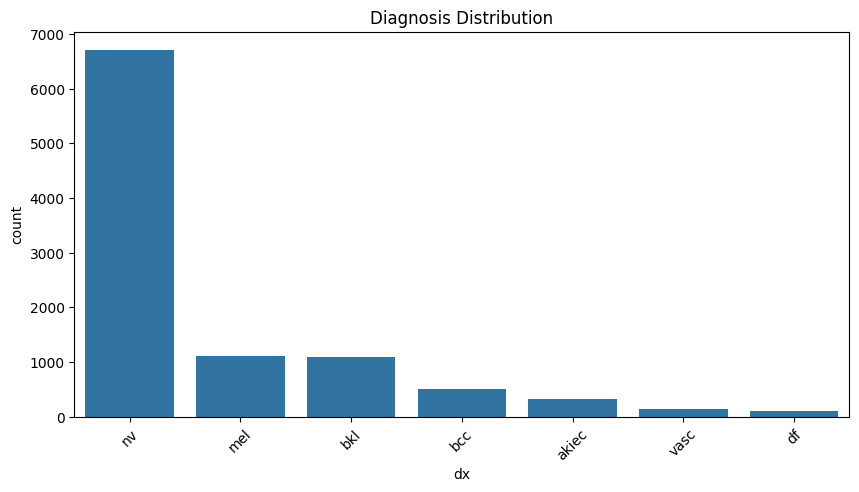

dx
nv       66.949576
mel      11.113330
bkl      10.973540
bcc       5.132302
akiec     3.265102
vasc      1.417873
df        1.148278
Name: proportion, dtype: float64

In [6]:
plt.figure(figsize=(10,5))
sns.countplot(data=merged_df, x="dx", order=merged_df["dx"].value_counts().index)
plt.title("Diagnosis Distribution")
plt.xticks(rotation=45)
plt.show()

merged_df["dx"].value_counts(normalize=True) * 100


## 1.2 Demographic Patters

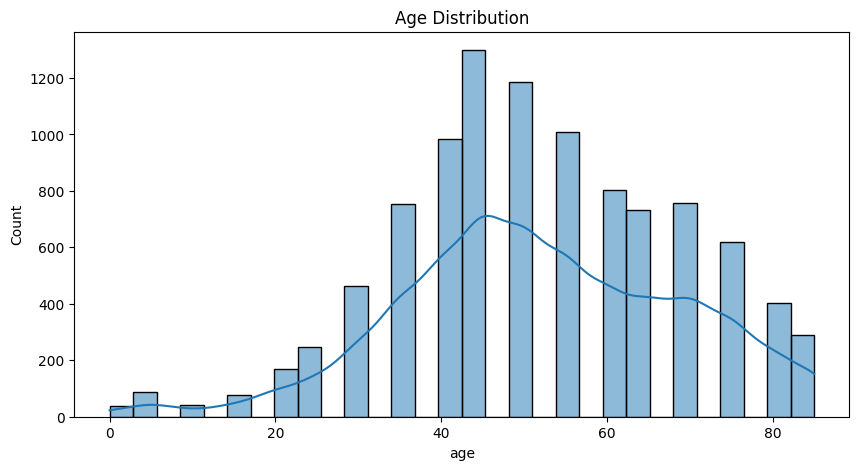

In [7]:
# Age Distribution
plt.figure(figsize=(10,5))
sns.histplot(merged_df["age"], kde=True, bins=30)
plt.title("Age Distribution")
plt.show()

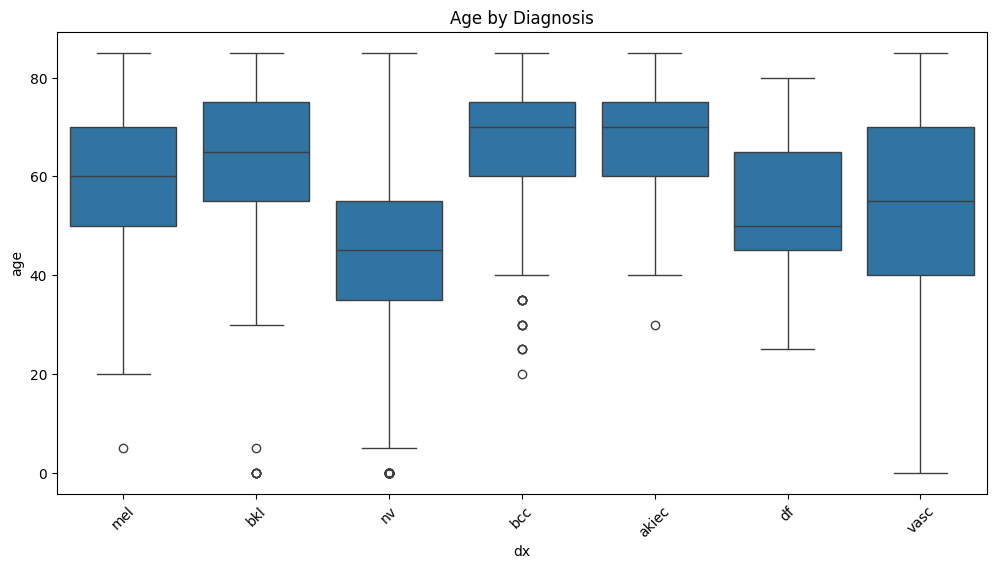

In [8]:
#Age vs diagnosis
plt.figure(figsize=(12,6))
sns.boxplot(data=merged_df, x="dx", y="age")
plt.xticks(rotation=45)
plt.title("Age by Diagnosis")
plt.show()

C:\Users\faust\AppData\Local\Temp\ipykernel_28360\941309233.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x="dx", y="age", order=dx_order, palette="Set2", ax=axes[0])


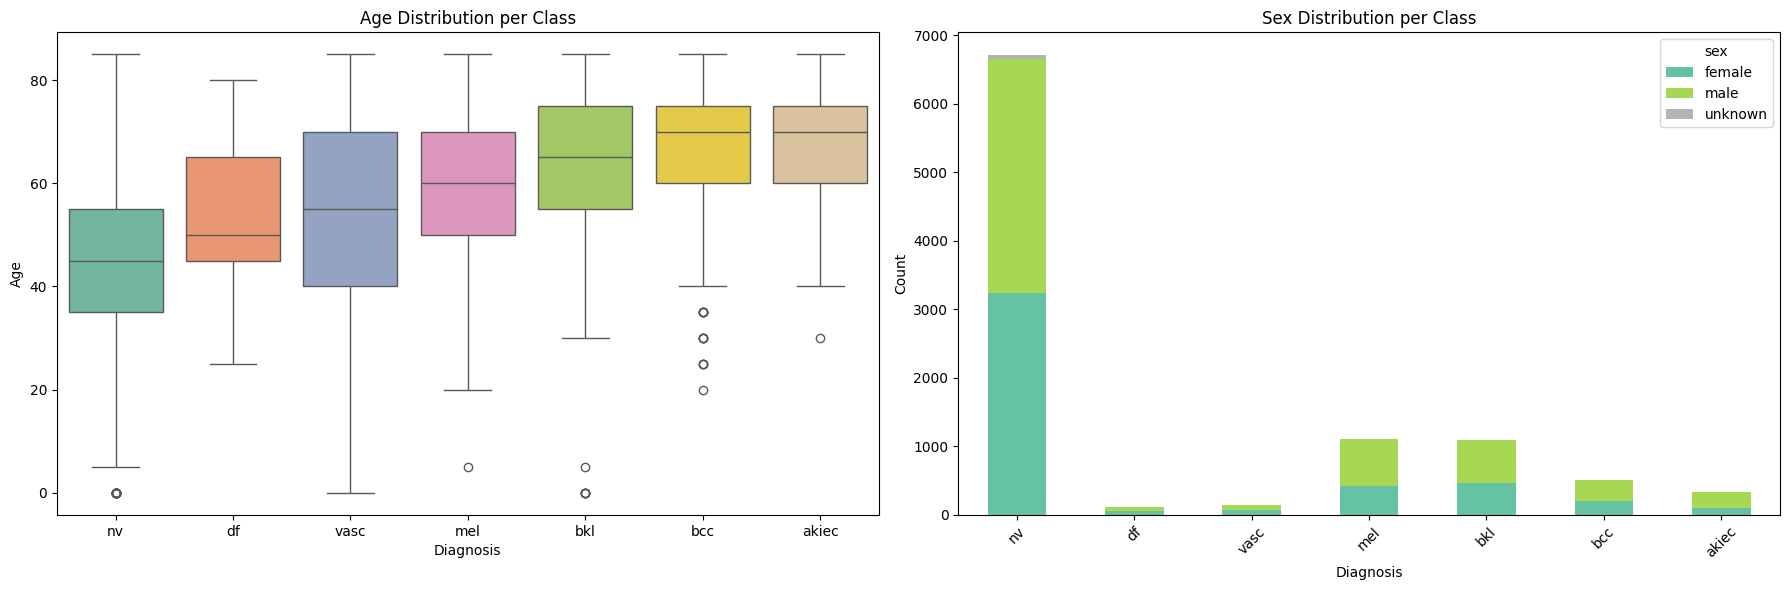

In [9]:
# Age & Sex distribution per class - tomas

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Age
dx_order = merged_df.groupby("dx")["age"].median().sort_values().index

sns.boxplot(data=merged_df, x="dx", y="age", order=dx_order, palette="Set2", ax=axes[0])
axes[0].set_title("Age Distribution per Class")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Age")

# Sex
sex_counts = merged_df.groupby(["dx", "sex"]).size().unstack(fill_value=0)
sex_counts = sex_counts.loc[dx_order]  # same order as boxplot
sex_counts.plot(kind="bar", stacked=True, colormap="Set2", ax=axes[1])
axes[1].set_title("Sex Distribution per Class")
axes[1].set_xlabel("Diagnosis")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 1.3 Body Location

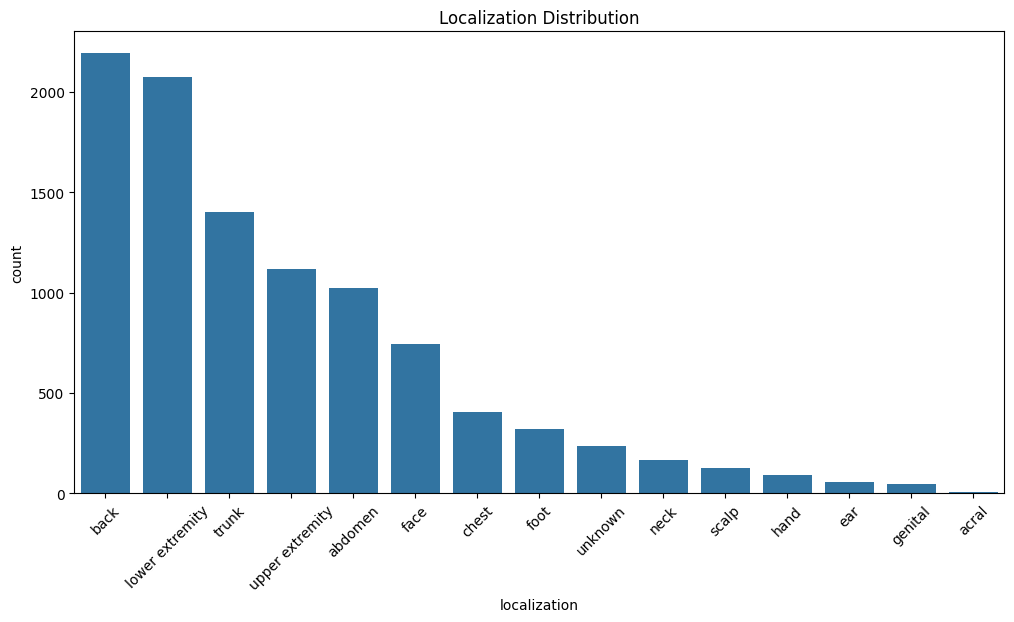

In [10]:
plt.figure(figsize=(12,6))
sns.countplot(data=merged_df, x="localization", order=merged_df["localization"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Localization Distribution")
plt.show()

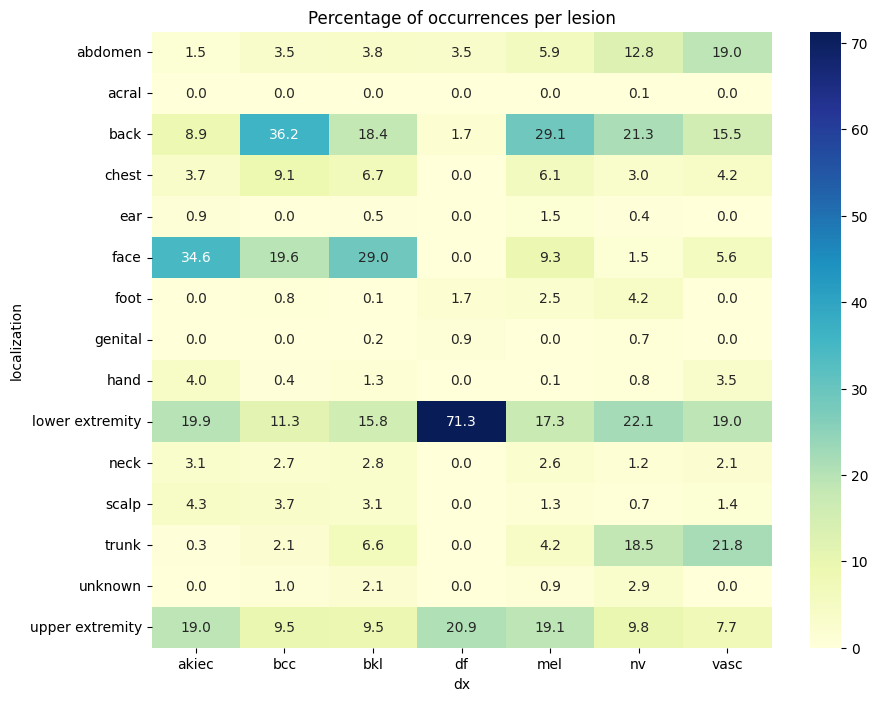

In [11]:
#bruna
ct = pd.crosstab(merged_df['localization'], merged_df['dx'], normalize='columns') * 100

plt.figure(figsize=(10, 8))
sns.heatmap(ct, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Percentage of occurrences per lesion')
plt.show()

C:\Users\faust\AppData\Local\Temp\ipykernel_28360\167920156.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='localization', y='age', data=merged_df, palette='viridis')


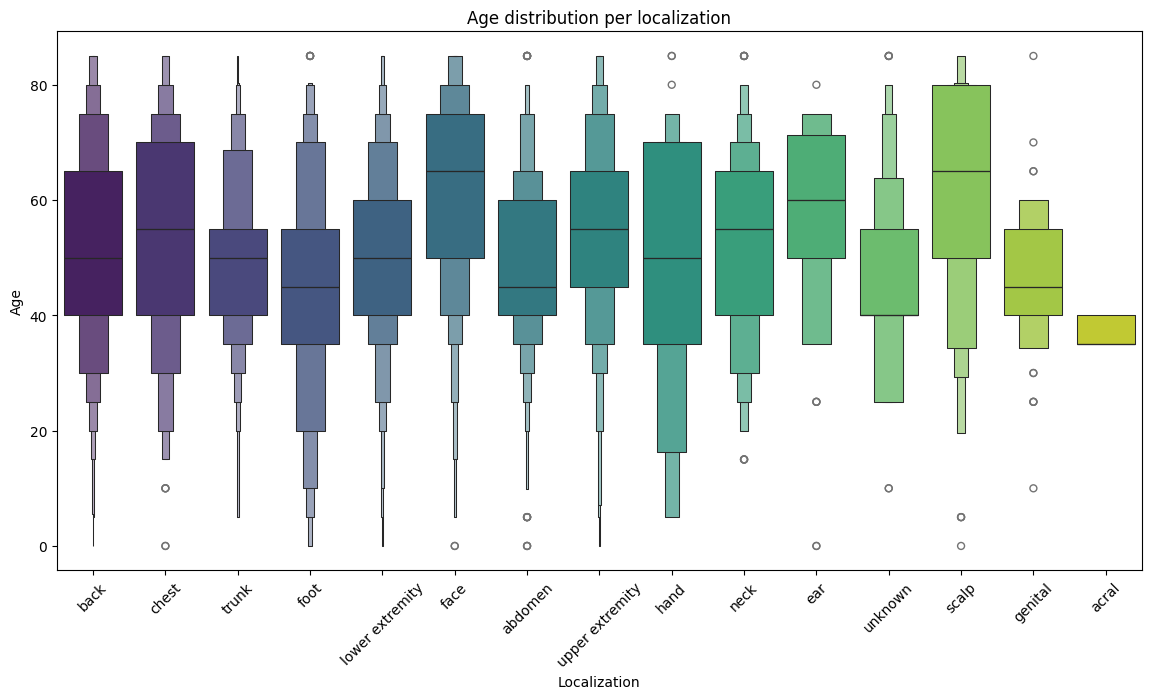

In [12]:
# bruna
plt.figure(figsize=(14, 7))
sns.boxenplot(x='localization', y='age', data=merged_df, palette='viridis')
plt.xticks(rotation=45)
plt.title('Age distribution per localization')
plt.xlabel('Localization')
plt.ylabel('Age')
plt.show()

## 1.4 Image Level EDA

In [13]:
# The old Colab path that is stuck in your CSV
colab_prefix = "/content/drive/MyDrive/MDSAA-DS/DL-project/dataverse_files/"

# Your new local path (update this if your folder structure is different!)
local_prefix = "./data/"

# Replace the old prefix with the new one across the whole column
merged_df["image_path"] = merged_df["image_path"].str.replace(colab_prefix, local_prefix)

# Quick check to verify the paths look correct now
print(merged_df["image_path"].head())

0    ./data/HAM10000_images_part_1/ISIC_0028291.jpg
1    ./data/HAM10000_images_part_1/ISIC_0028308.jpg
2    ./data/HAM10000_images_part_1/ISIC_0028286.jpg
3    ./data/HAM10000_images_part_1/ISIC_0028288.jpg
4    ./data/HAM10000_images_part_1/ISIC_0028313.jpg
Name: image_path, dtype: str


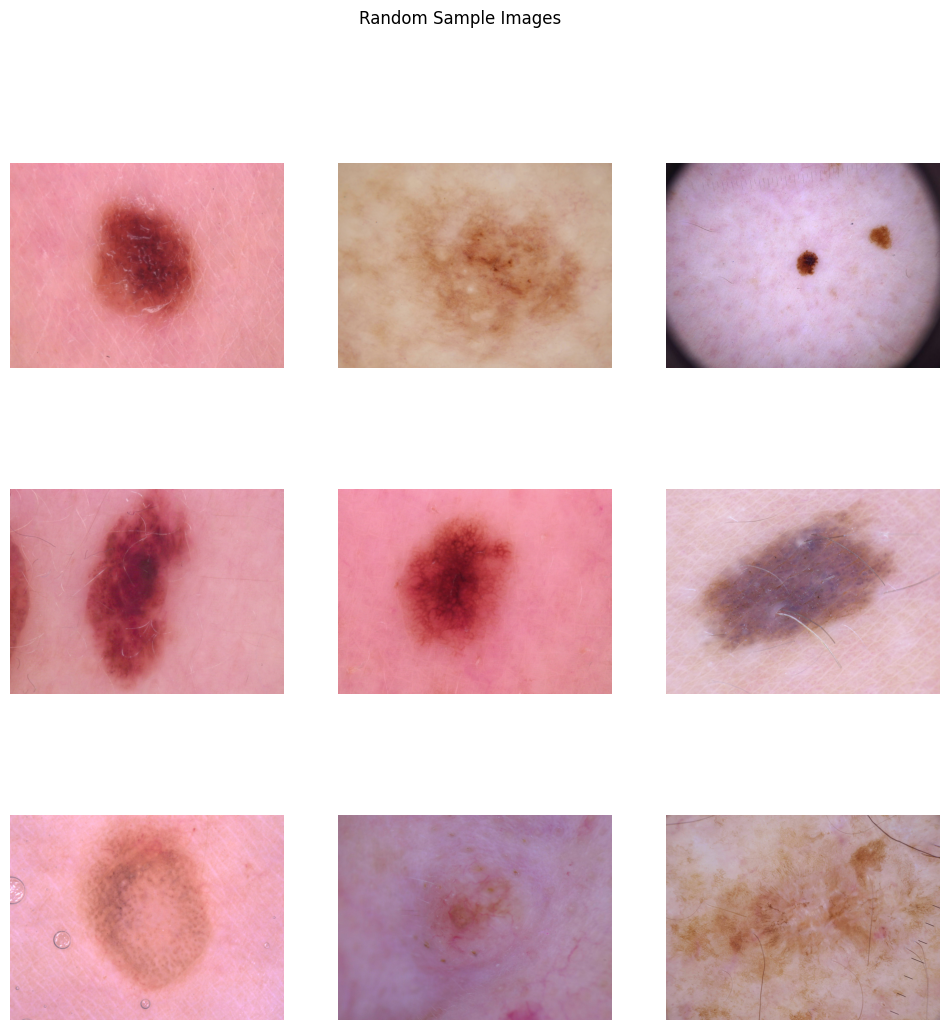

In [14]:
# Display random images

sample_paths = merged_df["image_path"].sample(9).tolist()

plt.figure(figsize=(12,12))
for i, path in enumerate(sample_paths):
    plt.subplot(3,3,i+1)
    img = Image.open(path)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle("Random Sample Images")
plt.show()

In [15]:
# Mode types exploration (RGB) - tomas

modes = []
for path in tqdm(merged_df["image_path"]):
    img = Image.open(path)
    modes.append(img.mode)

print(Counter(modes))

100%|██████████| 10015/10015 [00:01<00:00, 8129.69it/s]

Counter({'RGB': 10015})


100%|██████████| 10015/10015 [00:01<00:00, 8272.95it/s]


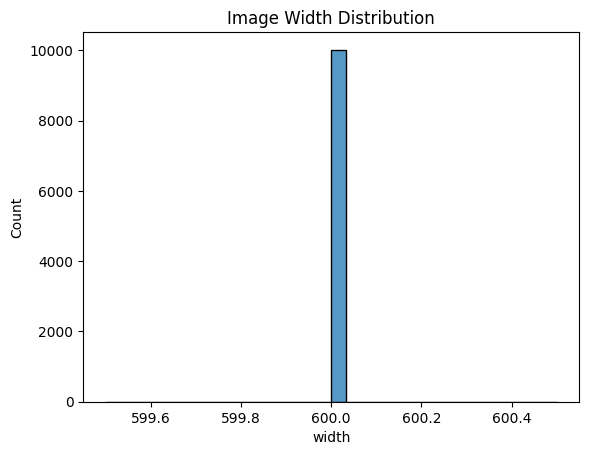

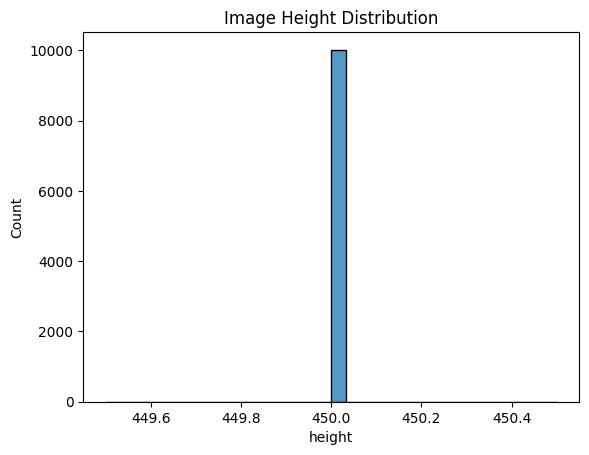

In [16]:
# Image size distribution

widths, heights = [], []

for path in tqdm(merged_df["image_path"]):
    img = Image.open(path)
    widths.append(img.size[0])
    heights.append(img.size[1])

merged_df["width"] = widths
merged_df["height"] = heights

sns.histplot(merged_df["width"], bins=30)
plt.title("Image Width Distribution")
plt.show()

sns.histplot(merged_df["height"], bins=30)
plt.title("Image Height Distribution")
plt.show()

In [ ]:
# Color Statistics

means = []
stds = []

for path in tqdm(merged_df["image_path"]):
    img = np.array(Image.open(path)) / 255.0
    means.append(img.mean())
    stds.append(img.std())

merged_df["img_mean"] = means
merged_df["img_std"] = stds

sns.histplot(merged_df["img_mean"], bins=30)
plt.title("Image Brightness Distribution")
plt.show()

sns.histplot(merged_df["img_std"], bins=30)
plt.title("Image Contrast Distribution")
plt.show()

 34%|███▍      | 3404/10015 [00:30<00:54, 121.10it/s]

In [ ]:
# Average Image per class - tomas

classes = merged_df["dx"].unique()

fig, axes = plt.subplots(1, len(classes), figsize=(len(classes) * 3, 4))

for i, cls in enumerate(classes):
    class_df = merged_df[merged_df["dx"] == cls]

    # Load images and calculate mean
    images_list = []
    for path in tqdm(class_df["image_path"], desc=f"Loading {cls}"):
        img = Image.open(path).convert('RGB')  # Ensure RGB format
        images_list.append(np.array(img))

    mean_img = np.mean(images_list, axis=0).astype(np.uint8)

    axes[i].imshow(mean_img)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis("off")

plt.suptitle("Average Image per Class", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# images for each unique lesion - bruna

count_lesions = merged_df.groupby('lesion_id').size().value_counts().sort_index()

plt.figure(figsize=(8, 5))
count_lesions.plot(kind='bar')
plt.title('Images per unique lesion')
plt.xlabel('Number of images for the same lesion')
plt.ylabel('Lesion Quantity')
plt.show()

## 1.5 Lesion ID Analysis

In [ ]:
lesion_counts = merged_df["lesion_id"].value_counts()
lesion_counts.describe()

sns.histplot(lesion_counts, bins=20)
plt.title("Images per Lesion")
plt.show()

# Check lesions with multiple images
lesion_counts[lesion_counts > 1].head()

## 1.6 Confirmation Method Analysis

In [ ]:
# bruna
conf_ct = pd.crosstab(merged_df['dx'], merged_df['dx_type'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(conf_ct, annot=True, cmap='Purples', fmt='.1f')
plt.title('Percentage of Confirmation Method for each Diagnosis (%)')
plt.xlabel('Confirmation Method (Ground Truth)')
plt.ylabel('Lesion Type')
plt.show()

## 1.7 Advanced Visual EDA (UMAP on Image Embeddings)

In [ ]:
model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()

transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor()
])

embeddings = []

for path in tqdm(merged_df["image_path"]):
    img = Image.open(path).convert("RGB")
    x = transform(img).unsqueeze(0)
    with torch.no_grad():
        emb = model(x).squeeze().numpy()
    embeddings.append(emb)

reducer = umap.UMAP()
embedding_2d = reducer.fit_transform(embeddings)

plt.figure(figsize=(10,8))
sns.scatterplot(x=embedding_2d[:,0], y=embedding_2d[:,1], hue=merged_df["dx"], palette="tab10")
plt.title("UMAP of Image Embeddings")
plt.show()


## 1.8 Black Filter Test

In [ ]:
# nao sei se coloque aqui ou nao - bruna

# 2. Data Quality Verification

## 2.1 Missing Values

In [ ]:
# Count missing values per column
merged_df.isna().sum()

# Percentage of missing values
merged_df.isna().mean() * 100

NameError: name 'merged_df' is not defined

## 2.2 Outlier Detection

In [ ]:
# Summary statistics
merged_df.describe()


In [ ]:
# Age outliers
outliers_age = merged_df[(merged_df["age"] < 1) | (merged_df["age"] > 100)]
outliers_age


In [ ]:
# Brightness/contrast outliers
merged_df[merged_df["img_mean"] > merged_df["img_mean"].quantile(0.99)]
merged_df[merged_df["img_std"] < merged_df["img_std"].quantile(0.01)]

## 2.3 Duplicate Rows

In [ ]:
# Exact duplicate rows
merged_df.duplicated().sum()

# Show duplicates
merged_df[merged_df.duplicated()]

# Duplicate image paths
merged_df[merged_df["image_path"].duplicated()]

# Lesions with multiple images (not an error, but important)
merged_df["lesion_id"].value_counts().head()

# 3. Preprocessing

## 3.1 Missing Values Treatment

### 3.1.1 Analysis

In [2]:
age_nulls = merged_df[merged_df['age'].isnull()]
print(f"Total number of rows with null age: {len(age_nulls)}")

# see if these missing values belong to a specific diagnose
print(age_nulls['dx'].value_counts())

NameError: name 'merged_df' is not defined

In [ ]:
babies_df = merged_df[merged_df['age'] == 0].sample(min(5, len(merged_df[merged_df['age'] == 0])))

# see if these missing values could mean "no year" / months of ages / babies
plt.figure(figsize=(20, 10))
for i, (index, row) in enumerate(babies_df.iterrows()):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(row['image_path'])
    plt.imshow(img)
    plt.title(f"ID: {row['image_id']}\nDx: {row['dx']}\nLocal: {row['localization']}")
    plt.axis('off')

plt.tight_layout()
plt.show()

The previous visualization attempts were inclusive. Due to the standardized close-up nature of dermoscopic images, we cannot confirm or deny if cases of Age 0 or NaN correspond to infants simply by analyzing skin texture, scale, or the presence of hair.

However, a multivariate analysis linking the missing ages with the diagnoses (dx) provides crucial evidence. Our previous diagnosis table showed that there are 2 cases of Melanoma (mel) among the 57 individuals with missing ages.
From a clinical and statistical standpoint, pediatric melanoma is extremely rare. If we were to assume all 57 cases with missing age are infants (Age 0), the prevalence of melanoma within this subgroup would be unfeasibly high ($3.5\%$), indicating a massive statistical anomaly.

This strongly suggests that these 57 individuals are, in fact, **adults whose age information was lost during the data collection process**.


### 3.1.2 Imputation Strategy Benchmark

In [ ]:
imput_df = merged_df[['age', 'dx', 'sex', 'localization']].copy()

#one hot encoder for categorical
df_ohe = pd.get_dummies(imput_df, columns=['dx', 'sex', 'localization'])

#1-KNN imputer
knn_imputer = KNNImputer(n_neighbors=5)
imputed_knn_data = knn_imputer.fit_transform(df_ohe)

#2-iterative imputer
it_imputer = IterativeImputer(random_state=42, max_iter=10)
imputed_it_data = it_imputer.fit_transform(df_ohe)

imput_df['age_knn'] = imputed_knn_data[:, 0]
imput_df['age_iterative'] = imputed_it_data[:, 0]
imput_df['age_median'] = imput_df['age'].fillna(imput_df['age'].median())

print(imput_df[['age', 'age_knn', 'age_iterative', 'age_median']].head())

In [ ]:
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

plot_params = [
    (imput_df['age'].dropna(), 'Original', 'black', 4, '-'),
    (imput_df['age_median'], 'Median', 'red', 2, '--'),
    (imput_df['age_knn'], 'KNN Imputer', 'blue', 2, ':'),
    (imput_df['age_iterative'], 'Iterative Imputer', 'green', 2, '-.')
]

for data, label, color, width, style in plot_params:
    sns.kdeplot(data, label=label, color=color, lw=width, ls=style, ax=ax1)
    sns.kdeplot(data, label=label, color=color, lw=width, ls=style, ax=ax2)

# graph 1: complete view
ax1.set_title('Global Age Distribution')
ax1.set_xlabel('Age')
ax1.legend()

# graph 2: zoom in the max
median = imput_df['age'].median()
ax2.set_xlim(median - 15, median + 15)
ax2.set_title(f'Zoom in the area of age {int(median)}')
ax2.set_xlabel('Age (for the interval)')
ax2.legend()

plt.tight_layout()
plt.show()

This analysis confirms that the Iterative Imputer is the best strategy for this dataset. While Median imputation introduces a significant artificial spike that distorts the natural age distribution, the Iterative method closely represents the original curve. By preserving the statistical variance and population density, this approach prevents the neural network from learning biased patterns during training. Therefore, the **Iterative Imputer** is chosen as the final method to ensure high data integrity.

### 3.1.3 Imputation Implementation

In [ ]:
merged_df['age'] = imput_df['age_iterative']

In [ ]:
print(f"Age nulls after IterativeImputer implementation: {merged_df['age'].isnull().sum()}")

With this implementation, the dataset achieves 100% completion and provides a high quality base for the subsequent pre processing stages.

## 3.2 Outliers

This section focuses exclusively on the identification and treatment of technical outliers.
In the context of medical imaging, we considered that clinical outliers (rare or atypical lesions) should be completely preserved, as they are the core of the study. Therefore, the focus will be on technical outliers, since they can degrade model performance and should be flagged for review.

In [ ]:
# METER NUM .PY FILE!!!!

def show_images(df, title, n=12):
    """Mostra uma grelha de imagens para inspeção visual."""
    plt.figure(figsize=(15, 12))
    sample = df.sample(min(n, len(df)))

    for i, (_, row) in enumerate(sample.iterrows()):
        plt.subplot(3, 4, i+1)
        img = Image.open(row["image_path"])
        plt.imshow(img)
        plt.title(row["image_id"], fontsize=8)
        plt.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


### 3.2.1 Brightness and Contrast

Images with extreme pixel‑intensity statistics using the 1st and 99th percentiles:
  - High brightness outliers - images that are overexposed
  - Low brightness outliers - images that are underexposed
  - Low contrast outliers - images lacking texture information

In [ ]:
# thresholds
bright_thr = merged_df["img_mean"].quantile(0.99)
dark_thr   = merged_df["img_mean"].quantile(0.01)
low_contrast_thr = merged_df["img_std"].quantile(0.01)

# subsets
outliers_bright = merged_df[merged_df["img_mean"] > bright_thr]
outliers_dark = merged_df[merged_df["img_mean"] < dark_thr]
outliers_low_contrast = merged_df[merged_df["img_std"] < low_contrast_thr]

print(len(outliers_bright), "bright outliers")
print(len(outliers_dark), "dark outliers")
print(len(outliers_low_contrast), "low contrast outliers")

In [ ]:
show_images(outliers_bright, "Top 1% Brightest Images")
show_images(outliers_dark, "Bottom 1% Darkest Images")
show_images(outliers_low_contrast, "Bottom 1% Contrast Images")

Visual inspection of the statistical outliers based on pixel intensity quantiles revealed critical acquisition patterns that could impact model generalization:

- High Brightness (Overexposure): The top 1% brightest images frequently exhibit "washed-out" skin tones possibly caused by aggressive flash photography and/or naturally lighter skin tones.

- Low Brightness & Vignetting: Some skin lesions have typically daker tones, nevertheless, a few darkest outliers suffer from significant vignetting (radial darkening) and/or body hair. This optical artifact skews the global intensity mean and risks introducing a "shortcut" where the model might incorrectly associate dark borders with specific pathological classes.

**Technical Implications:** While both cases could impact the model, the lesion morphology remains largely visible, meaning we shouldn't remove them. These findings justify the implementation of Color Normalization (e.g., Shades of Gray) and Histogram Equalization (CLAHE) to standardize the illumination profile across the dataset, which should be considered for the dataset preparation to modelling.



### 3.2.2. Semantic Outliers via UMAP Embeddings

  - Extract deep embeddings using a pretrained ResNet18
  - Project them into 2D space using UMAP
  - Compute each image’s distance to the embedding centroid
  - Flag the top 1% most distant samples

In [ ]:
# Outliers no UMAP (embeddings isolados)

from sklearn.metrics import pairwise_distances

# centroide do embedding
centroid = embedding_2d.mean(axis=0)

# distância de cada ponto ao centro
distances = pairwise_distances(embedding_2d, centroid.reshape(1, -1)).flatten()

merged_df["umap_dist"] = distances

# top 1% mais distantes
umap_thr = merged_df["umap_dist"].quantile(0.99)
outliers_umap = merged_df[merged_df["umap_dist"] > umap_thr]

print("UMAP outliers:", len(outliers_umap))
show_images(outliers_umap, "UMAP Outliers (Isolated Embeddings)")


The UMAP dimensional projection successfully isolated a cluster of images whose distance from the embedding centroid is significantly higher than the dataset average. Analysis of these samples reveals a dominant confounding factor:

- Occlusion by Body Hair: Nearly 100% of the identified UMAP outliers display a high density of terminal hair overlying the lesion. The presence of high-contrast, dark linear structures creates a digital signature that "drowns out" the underlying morphological features. The fact that UMAP isolates these images proves that hair is not merely visual noise, but a structural feature that fundamentally shifts the latent distribution of the data.

**Mitigation Strategy**: To prevent the Deep Learning model from learning non-biological artifacts, a Hair Removal pipeline (e.g., DullRazor) is required. This step ensures the CNN focuses on dermatological patterns rather than occlusion artifacts.

In [ ]:
# COLUNA FINAL DE OUTLIERS

merged_df["is_outlier"] = False

merged_df.loc[outliers_bright.index, "is_outlier"] = True
merged_df.loc[outliers_dark.index, "is_outlier"] = True
merged_df.loc[outliers_low_contrast.index, "is_outlier"] = True
merged_df.loc[outliers_umap.index, "is_outlier"] = True

merged_df["is_outlier"].value_counts()

In [ ]:
# REMOÇÃO - OPCIONAL -> TOMAR DECISÃO

clean_df = merged_df[~merged_df["is_outlier"]].copy()
print("Original:", len(merged_df))
print("Clean:", len(clean_df))

## 3.2.3 Outlier Remediation Pipeline

To ensure the Deep Learning model learns dermatological features rather than photographic characteristucs, we apply a three-step cleaning process.

1. **Hair Removal (DullRazor Algorithm)**
Since hairs are high-contrast linear occlusions, we use the DullRazor approach:
    - Morphological Blackhat Filtering: Isolate dark, thin structures from the background.
    - Binary Masking: Create a precise map of every hair strand.
    - Telea Inpainting: Replace the "hair pixels" with a smooth interpolation of the surrounding skin texture.

2. **Spatial Standardization (Center Cropping)**
To mitigate Vignetting (dark corners) and focus the model's attention:
    - We perform a 10% marginal crop on all sides.
    - Since clinical dermoscopy typically centers the lesion, this removes the most distorted parts of the lens frame without losing diagnostic data.

3. **Illumination Normalization (CLAHE)**
To handle Overexposure and Low Contrast:
    - We convert the image to the CIE Lab color space.
    - We apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to the L (Luminance) channel. CLAHE enhances local contrast in small tiles, bringing back "washed out" details in bright areas without amplifying noise.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

def dull_razor(img):
    """Removes hair artifacts using morphological blackhat filtering."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    dst = cv2.inpaint(img, mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    return dst

def fix_illumination(img):
    """Standardizes brightness via CLAHE and removes peripheral vignetting."""
    # 1. Center Crop (10% margin removal to eliminate lens vignetting)
    h, w = img.shape[:2]
    img = img[int(h*0.1):int(h*0.9), int(w*0.1):int(w*0.9)]

    # 2. CLAHE on the L-channel (Lab color space)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    img_corrected = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2RGB)
    return img_corrected

In [ ]:
# Define destination path
processed_base_path = os.path.join(base_path, "HAM10000_cleaned")
if not os.path.exists(processed_base_path):
    os.makedirs(processed_base_path)

merged_df["cleaned_path"] = ""

# Sequential processing loop
for idx, row in tqdm(merged_df.iterrows(), total=len(merged_df), desc="Cleaning & Saving"):
    try:
        # Load
        img = cv2.imread(row["image_path"])
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Process
        img = dull_razor(img)
        img = fix_illumination(img)
        img = cv2.resize(img, (224, 224)) # Standard size for CNN input

        # Save
        new_filename = f"{row['image_id']}_cleaned.jpg"
        new_path = os.path.join(processed_base_path, new_filename)
        cv2.imwrite(new_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

        # Update DataFrame
        merged_df.at[idx, "cleaned_path"] = new_path
    except Exception as e:
        print(f"Error processing {row['image_id']}: {e}")

# Save updated metadata
merged_df.to_csv(os.path.join(base_path, "merged_df_cleaned.csv"), index=False)

In [ ]:
def verify_remediation(df, num_samples=3):
    # Target images previously identified as UMAP outliers
    samples = df[df["umap_dist"] > umap_thr].head(num_samples)

    fig, axes = plt.subplots(num_samples, 2, figsize=(12, num_samples * 5))

    for i, (idx, row) in enumerate(samples.iterrows()):
        # Load Original
        orig = cv2.imread(row["image_path"])
        orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

        # Load Cleaned
        cleaned = cv2.imread(row["cleaned_path"])
        cleaned = cv2.cvtColor(cleaned, cv2.COLOR_BGR2RGB)

        axes[i, 0].imshow(orig)
        axes[i, 0].set_title(f"Original (Outlier): {row['image_id']}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(cleaned)
        axes[i, 1].set_title(f"Cleaned and Standardized - remotion of body hair")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

verify_remediation(merged_df)